### 1: Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import unittest  # Libreria estandar para la automatizacion de pruebas de software
import warnings
warnings.filterwarnings('ignore') # Bloquear advertencias visuales para mantener limpia la salida

print("Celda 1: Entorno de alta calidad configurado. Librerias matematicas y neuronales listas.")

Celda 1: Entorno de alta calidad configurado. Librerias matematicas y neuronales listas.


### 2: Hiperparámetros y Selección del Producto

In [2]:
PRODUCTO_OBJETIVO = 'ARÁNDANO'
LOOK_BACK = 7    # Ventana temporal adaptativa (1 semana de memoria secuencial)
EPOCHS = 100     # Epocas balanceadas para evitar sobreajuste (overfitting)
BATCH_SIZE = 16  # Tamano de lote pequeno para mejor convergencia y estabilidad de gradientes

# Atributos del ecosistema actualizados con codificación cíclica temporal (seno y coseno)
FEATURES_COLS = ['Precio_Hoy_Kg', 'Diesel_Lima_Soles', 'emergencias_activas', 'dia_semana_seno', 'dia_semana_coseno']

print(f"Celda 2: Hiperparametros establecidos. Monitoreando comportamiento del: {PRODUCTO_OBJETIVO}")

Celda 2: Hiperparametros establecidos. Monitoreando comportamiento del: ARÁNDANO


### 3: Carga, Fusión y Filtros de Calidad de Datos (Sanity Checks)

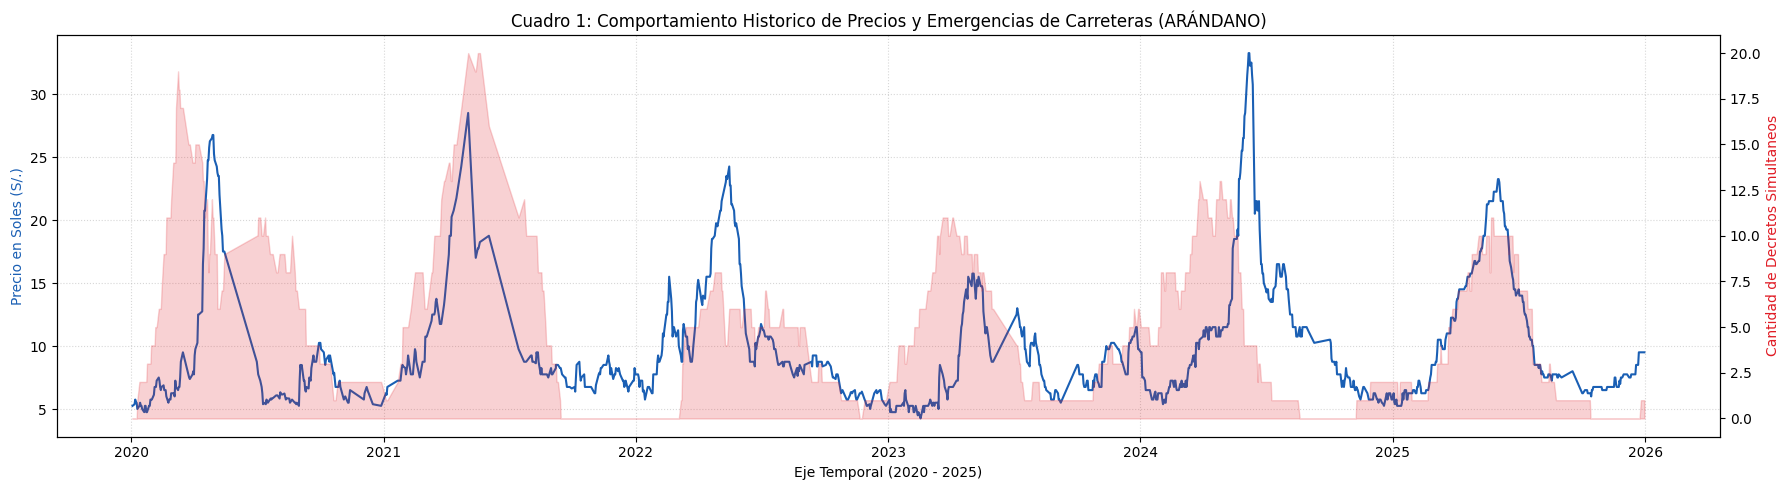

Celda 3: Datos curados y validados. Registros finales listos: 1250 dias continuos.


In [3]:
# PILAR 1: CALIDAD DE DATOS -> Asegurar completitud, tipos y rangos logicos.

# 1. Carga cruda desde los repositorios de almacenamiento CSV
df_productos = pd.read_csv('dataset_productos_anual.csv')
df_decretos = pd.read_csv('decretos_fluviales_anuales.csv')
df_diesel = pd.read_csv('precios_diesel_anual.csv')

# 2. Control de Consistencia de Tipos: Parseo explicito a formato Datetime corporativo
df_productos['Fecha'] = pd.to_datetime(df_productos['Fecha'], errors='coerce')
df_aran = df_productos[df_productos['Producto'] == PRODUCTO_OBJETIVO].copy()

# 3. Control de Completitud: Eliminar registros sin fecha indexable
df_aran = df_aran.dropna(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

# 4. PRUEBA DE CALIDAD DE DATOS (Rangos Logicos - Sanity Check)
anomalias_precios = (df_aran['Precio_Hoy_Kg'] <= 0).sum()
if anomalias_precios > 0:
    print(f"ALERTA DE CALIDAD: Se detectaron {anomalias_precios} filas con precios inconsistentes (<= 0). Aplicando remocion tecnica...")
    df_aran = df_aran[df_aran['Precio_Hoy_Kg'] > 0]

# Extraccion de llaves temporales
df_aran['Anio'] = df_aran['Fecha'].dt.year
df_aran['mes_num'] = df_aran['Fecha'].dt.month

# *** MEJORA DE INGENIERÍA: Codificación cíclica del día de la semana ***
dia_semana = df_aran['Fecha'].dt.dayofweek
df_aran['dia_semana_seno'] = np.sin(2 * np.pi * dia_semana / 7)
df_aran['dia_semana_coseno'] = np.cos(2 * np.pi * dia_semana / 7)

# 5. Cruzado de Decretos de Emergencia
df_decretos['Fecha_Inicio'] = pd.to_datetime(df_decretos['Fecha_Inicio'], dayfirst=True)
df_decretos['Fecha_Fin'] = pd.to_datetime(df_decretos['Fecha_Fin'], dayfirst=True)

def calcular_decretos_activos(fecha_dia):
    return ((df_decretos['Fecha_Inicio'] <= fecha_dia) & (df_decretos['Fecha_Fin'] >= fecha_dia)).sum()

df_aran['emergencias_activas'] = df_aran['Fecha'].apply(calcular_decretos_activos)

# 6. Fusion integradora con el historico de combustible
df_final = pd.merge(df_aran, df_diesel, on=['Anio', 'mes_num'], how='left')

# 7. Control de Completitud Final (No Gaps)
df_final = df_final.ffill().bfill()

# CUADRO VISUAL 1
fig, ax1 = plt.subplots(figsize=(18, 5))
ax2 = ax1.twinx()

ax1.plot(df_final['Fecha'], df_final['Precio_Hoy_Kg'], color='#1a5fb4', label='Precio del Arandano (S/. por Kg)', linewidth=1.5)
ax2.fill_between(df_final['Fecha'], df_final['emergencias_activas'], color='#e01b24', alpha=0.2, label='Alertas de Emergencia Vial Activas')

ax1.set_xlabel('Eje Temporal (2020 - 2025)')
ax1.set_ylabel('Precio en Soles (S/.)', color='#1a5fb4')
ax2.set_ylabel('Cantidad de Decretos Simultaneos', color='#e01b24')
plt.title(f'Cuadro 1: Comportamiento Historico de Precios y Emergencias de Carreteras ({PRODUCTO_OBJETIVO})')
ax1.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Celda 3: Datos curados y validados. Registros finales listos: {len(df_final)} dias continuos.")

### 4: Ingeniería de Atributos y Selección de Variables

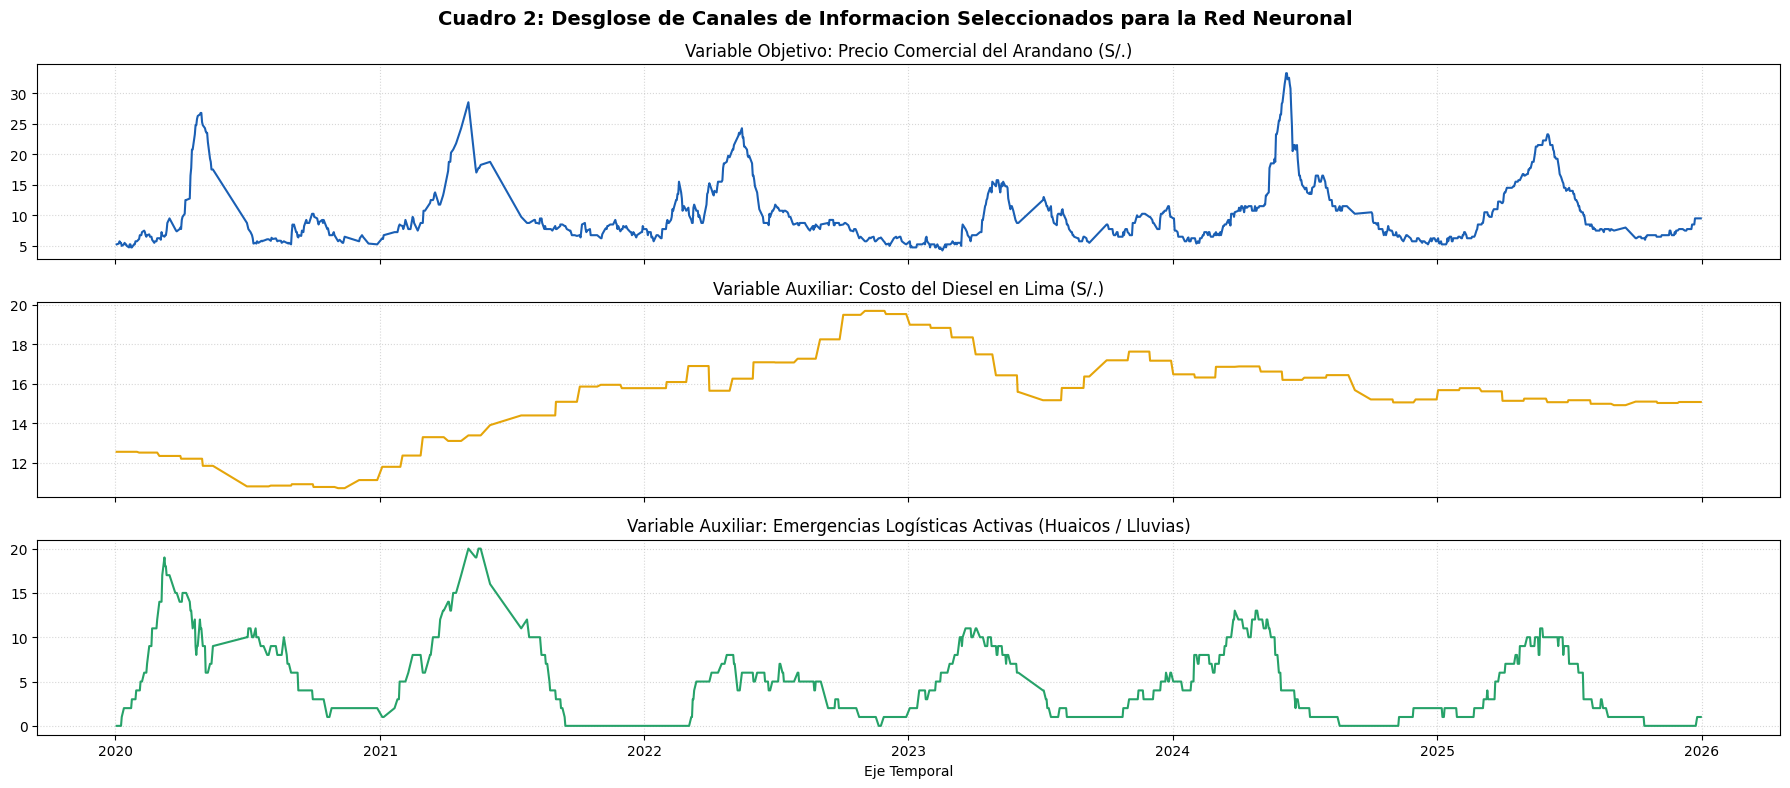

Celda 4: Caracteristicas seleccionadas bajo estricto orden matematico: ['Precio_Hoy_Kg', 'Diesel_Lima_Soles', 'emergencias_activas', 'dia_semana_seno', 'dia_semana_coseno']


In [4]:
# Extraer la matriz limpia con las dimensiones requeridas por el modelo
df_input_ready = df_final[FEATURES_COLS].copy()

# CUADRO VISUAL 2: Comportamiento de las Variables Regresoras del Ecosistema
fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

axes[0].plot(df_final['Fecha'], df_final['Precio_Hoy_Kg'], color='#1a5fb4')
axes[0].set_title('Variable Objetivo: Precio Comercial del Arandano (S/.)')
axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(df_final['Fecha'], df_final['Diesel_Lima_Soles'], color='#e5a50a')
axes[1].set_title('Variable Auxiliar: Costo del Diesel en Lima (S/.)')
axes[1].grid(True, linestyle=':', alpha=0.5)

axes[2].plot(df_final['Fecha'], df_final['emergencias_activas'], color='#26a269')
axes[2].set_title('Variable Auxiliar: Emergencias Logísticas Activas (Huaicos / Lluvias)')
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.xlabel('Eje Temporal')
plt.suptitle('Cuadro 2: Desglose de Canales de Informacion Seleccionados para la Red Neuronal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Celda 4: Caracteristicas seleccionadas bajo estricto orden matematico: {FEATURES_COLS}")

### 5: Preparación de Secuencias y Estrategia de Backtesting Temporal

In [5]:
# PILAR 2: CALIDAD DEL MODELO -> Backtesting SIN Filtración de Datos (Zero Leakage)

# 1. Separar lógicamente el dataset ANTES de calcular el escalador
filas_train = df_final['Anio'] < 2025
df_train_raw = df_input_ready[filas_train]

# 2. Ajustar (FIT) el escalador ÚNICAMENTE con la data de entrenamiento
scaler = MinMaxScaler(feature_range=(0.1, 1))
scaler.fit(df_train_raw.values)

# 3. Transformar TODO el dataset usando las reglas aprendidas del pasado
scaled_data = scaler.transform(df_input_ready.values)

# 4. Generador de secuencias matriciales de ventana deslizante
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), :]) # Ventana de tiempo (Variables regresoras)
        y.append(data[i + look_back, 0])     # Objetivo a predecir
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_data, LOOK_BACK)

# 5. MASCARA TEMPORAL DE CALIDAD: Separación cronológica estricta para validación
train_mask = (df_final['Anio'].iloc[LOOK_BACK:] < 2025).values
test_mask = (df_final['Anio'].iloc[LOOK_BACK:] == 2025).values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

# 6. Extracción de fechas correspondientes
fechas_secuencias = df_final['Fecha'].iloc[LOOK_BACK:].reset_index(drop=True)
fechas_test = fechas_secuencias[test_mask].reset_index(drop=True)

print(f"Dimensiones de Entrenamiento (2020-2024): X={X_train.shape}, y={y_train.shape}")
print(f"Dimensiones de Testeo a ciegas (2025): X={X_test.shape}, y={y_test.shape}")

Dimensiones de Entrenamiento (2020-2024): X=(977, 7, 5), y=(977,)
Dimensiones de Testeo a ciegas (2025): X=(266, 7, 5), y=(266,)


### 6: Arquitectura y Entrenamiento de la Red LSTM

Entrenando modelo con el set historico de calibracion (2020-2024)...


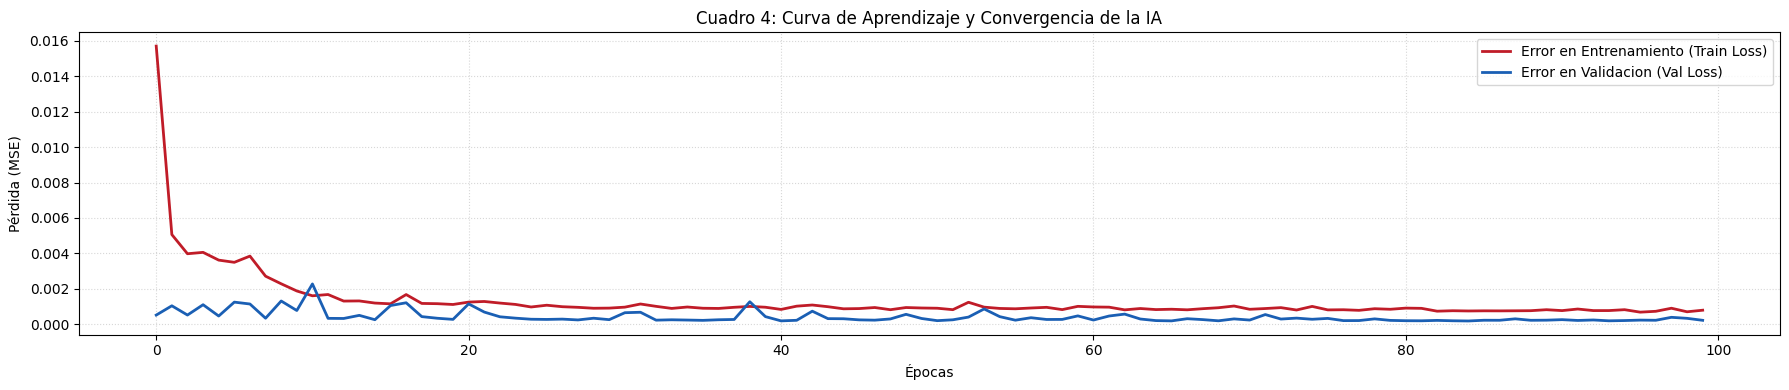

In [6]:
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        LSTM(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

print("Entrenando modelo con el set historico de calibracion (2020-2024)...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)

# CUADRO VISUAL 4: Curva de Aprendizaje y Convergencia de la IA
plt.figure(figsize=(18, 4))
plt.plot(history.history['loss'], color='#c01c28', linewidth=2, label='Error en Entrenamiento (Train Loss)')
plt.plot(history.history['val_loss'], color='#1a5fb4', linewidth=2, label='Error en Validacion (Val Loss)')
plt.title('Cuadro 4: Curva de Aprendizaje y Convergencia de la IA')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### 7: Extracción del Patrón Estacional Histórico


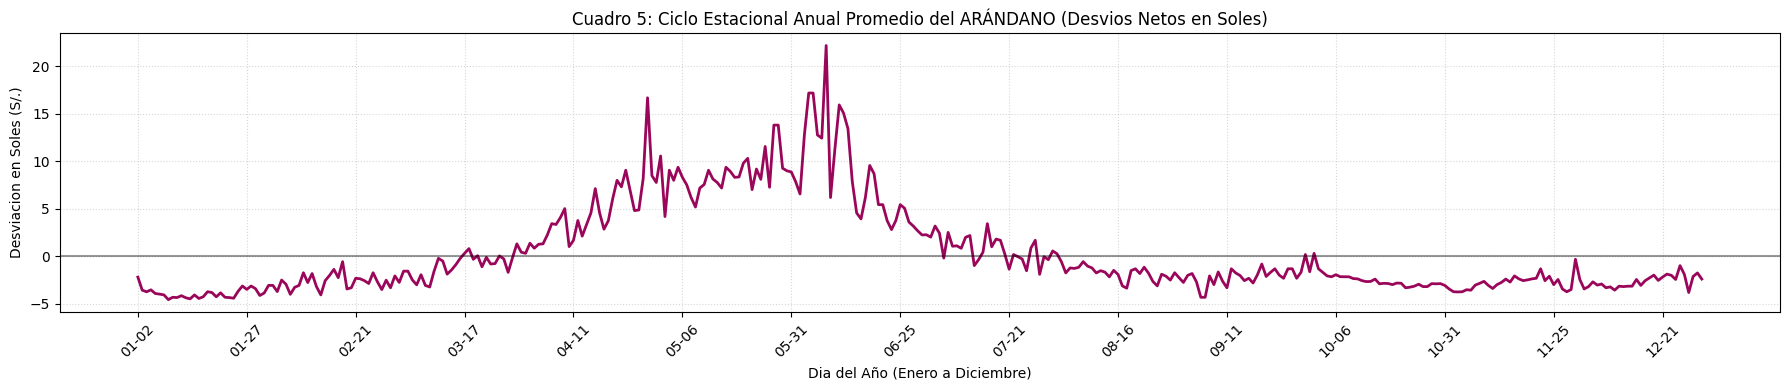

Celda 7: Desviacion estacional diaria calculada y guardada en memoria matematica.


In [7]:
df_final['Mes_Dia'] = df_final['Fecha'].dt.strftime('%m-%d')
media_historica_global = df_final['Precio_Hoy_Kg'].mean()

# Calculates the systematic deviation of the fruit
patron_estacional_diario = df_final.groupby('Mes_Dia')['Precio_Hoy_Kg'].mean() - media_historica_global

# CUADRO VISUAL 5: ADN Estacional del Producto Objetivo
plt.figure(figsize=(18, 4))
plt.plot(patron_estacional_diario.index, patron_estacional_diario.values, color='#9a065a', linewidth=2)
plt.axhline(0, color='black', linestyle='-', alpha=0.4)
plt.title(f'Cuadro 5: Ciclo Estacional Anual Promedio del {PRODUCTO_OBJETIVO} (Desvios Netos en Soles)')
plt.ylabel('Desviacion en Soles (S/.)')
plt.xlabel('Dia del Año (Enero a Diciembre)')
# Simplificar marcas del eje X para que no se amontonen las fechas
plt.xticks(plt.gca().get_xticks()[::25], rotation=45)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("Celda 7: Desviacion estacional diaria calculada y guardada en memoria matematica.")

### 8: Auditoría de Métricas de Calidad (Backtesting 2025) y Proyección 2026


REPORTE FORMAL DE CALIDAD DE LA IA (AÑO 2025)
MAE:  S/. 0.33 por Kilogramo.
RMSE: S/. 0.43 (Sensibilidad a picos).
MAPE: 3.46 % de desviación promedio.


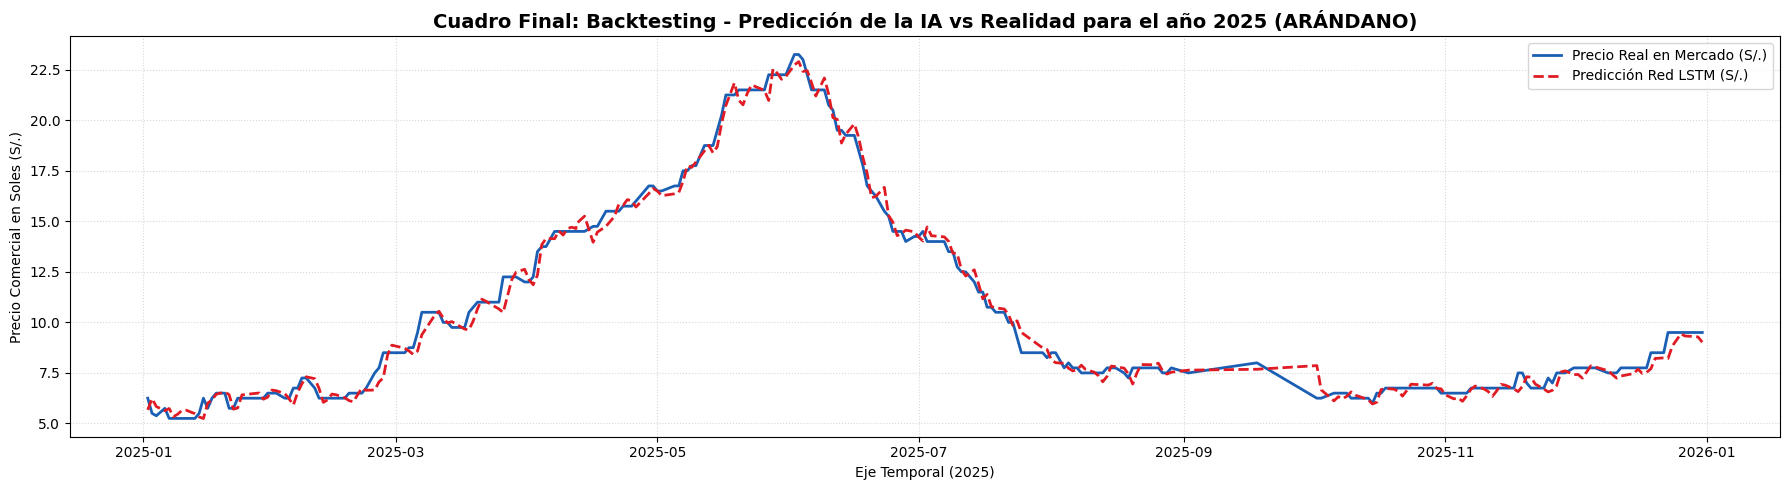

Celda 8: Evaluación final completada. Gráfico de Backtesting renderizado con éxito.


In [12]:
# PILAR 2: EVALUACION DE METRICAS Y PROYECCION REALISTA DEL MERCADO

# 1. Realizar predicciones sobre el año de prueba desasociado (2025)
y_pred_test_scaled = model.predict(X_test, verbose=0)

# 2. Desescalar los vectores para restaurar las magnitudes originales en Soles (S/.)
dummy_test = np.zeros((len(y_test), len(FEATURES_COLS)))
dummy_test[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy_test)[:, 0]

dummy_pred = np.zeros((len(y_pred_test_scaled), len(FEATURES_COLS)))
dummy_pred[:, 0] = y_pred_test_scaled.flatten()
y_pred_real = scaler.inverse_transform(dummy_pred)[:, 0]

# 3. Cálculo de métricas matemáticas
mae = np.mean(np.abs(y_test_real - y_pred_real))
rmse = np.sqrt(np.mean((y_test_real - y_pred_real)**2))
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print("\n" + "="*60)
print("REPORTE FORMAL DE CALIDAD DE LA IA (AÑO 2025)")
print("="*60)
print(f"MAE:  S/. {mae:.2f} por Kilogramo.")
print(f"RMSE: S/. {rmse:.2f} (Sensibilidad a picos).")
print(f"MAPE: {mape:.2f} % de desviación promedio.")
print("="*60)

# 4. CUADRO VISUAL: Proyección de la IA vs Realidad en el Mercado (2025)
plt.figure(figsize=(18, 5))
plt.plot(fechas_test, y_test_real, color='#1a5fb4', label='Precio Real en Mercado (S/.)', linewidth=2)
plt.plot(fechas_test, y_pred_real, color='#e01b24', label='Predicción Red LSTM (S/.)', linestyle='--', linewidth=2)

plt.title(f'Cuadro Final: Backtesting - Predicción de la IA vs Realidad para el año 2025 ({PRODUCTO_OBJETIVO})', fontsize=14, fontweight='bold')
plt.xlabel('Eje Temporal (2025)')
plt.ylabel('Precio Comercial en Soles (S/.)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("Celda 8: Evaluación final completada. Gráfico de Backtesting renderizado con éxito.")

### 9: Módulo Extendido de Pruebas Unitarias y de Estrés (Stress Testing)



In [11]:
# PILAR 3: CALIDAD DE CÓDIGO Y RESILIENCIA -> Suite automatizada para validar el software ante crisis de mercado.

class TestAgriPredictPipeline(unittest.TestCase):

    def setUp(self):
        self.df_test = df_final.copy()
        self.features = FEATURES_COLS
        self.look_back = LOOK_BACK
        self.scaler_test = scaler
        self.model_test = model

    def test_completitud_ausencia_nulos(self):
        """[Calidad de Datos] Verificar que los procesos de limpieza no dejen vacios (Gaps)"""
        for col in self.features:
            nulos = self.df_test[col].isna().sum()
            self.assertEqual(nulos, 0, f"Error: La columna '{col}' fallo el control de completitud (posee nulos).")

    def test_rangos_logicos_precios(self):
        """[Calidad de Datos] Confirmar que no existan distorsiones imposibles (Precios de Fruta <= 0)"""
        precios_invalidos = (self.df_test['Precio_Hoy_Kg'] <= 0).sum()
        self.assertEqual(precios_invalidos, 0, "Error de Calidad: Existen cotizaciones comerciales negativas o en cero.")

    def test_umbral_de_error_comercial(self):
        """[Calidad del Modelo] Comprobar si el MAPE matematico calculado esta dentro de rangos viables (< 35%)"""
        self.assertLess(mape, 35.0, f"Error de Precision: El MAPE obtenido ({mape:.2f}%) supera el limite permitido.")

    def test_prueba_estres_anomalias_mercado(self):
        """[Prueba de Estres] Stress Test: Simular un shock extremo (Anomalia) en las variables de entrada"""
        secuencia_estres = np.ones((1, self.look_back, len(self.features))) * 0.5
        secuencia_estres[0, -1, 2] = 1.0
        secuencia_estres[0, -1, 1] = 0.9

        try:
            prediccion_estres = self.model_test.predict(secuencia_estres, verbose=0)[0][0]
            self.assertFalse(np.isnan(prediccion_estres), "FALLO DE ESTRES: El modelo colapso y devolvio un valor NaN.")
            self.assertFalse(np.isinf(prediccion_estres), "FALLO DE ESTRES: La respuesta neuronal divergio a Infinito.")
            self.assertTrue(0.0 <= prediccion_estres <= 2.0, "FALLO DE ESTRES: La salida escalada rompio los limites logicos de la red.")
        except Exception as e:
            self.fail(f"El software fallo criticamente al procesar el escenario de shock de mercado: {str(e)}")

# MOTOR DE PRESENTACIÓN PERSONALIZADO (REPORTING DASHBOARD)
class DashboardTestResult(unittest.TestResult):
    def __init__(self):
        super().__init__()
        self.results = []

    def addSuccess(self, test):
        super().addSuccess(test)
        desc = test._testMethodDoc or test._testMethodName
        self.results.append((desc, "APROBADO", "Operando correctamente bajo los parametros corporativos establecidos."))

    def addFailure(self, test, err):
        super().addFailure(test, err)
        desc = test._testMethodDoc or test._testMethodName
        msg = str(err[1]).split('\n')[0]
        self.results.append((desc, "FALLADO", msg))

    def addError(self, test, err):
        super().addError(test, err)
        desc = test._testMethodDoc or test._testMethodName
        msg = str(err[1]).split('\n')[0]
        self.results.append((desc, "ERROR CRITICO", msg))

# Ejecucion de la auditoria e inyeccion en el formateador visual
suite = unittest.TestLoader().loadTestsFromTestCase(TestAgriPredictPipeline)
runner_result = DashboardTestResult()
suite.run(runner_result)

# Renderizado del reporte
print("\n" + "="*105)
print("             TABLERO EJECUTIVO DE AUDITORIA: CONTROL DE CALIDAD AGRI_PREDICT")
print("="*105)
print(f"{'DIMENSION / COMPROBACION EVALUADA':<65} | {'ESTADO':<10} | {'DETALLE Y OBSERVACIONES'}")
print("-" * 105)
for desc, estado, detalle in runner_result.results:
    print(f"{desc:<65} | {estado:<10} | {detalle}")
print("="*105)

# Calculo de indicadores globales
total_pruebas = runner_result.testsRun
total_incidentes = len(runner_result.failures) + len(runner_result.errors)
total_exitosos = total_pruebas - total_incidentes

print(f"RESUMEN DE AUDITORIA: Pruebas Totales: {total_pruebas} | Exitosas: {total_exitosos} | Incidentes: {total_incidentes}")
if total_incidentes == 0:
    print("ESTADO FINAL DEL SISTEMA: COMPATIBLE PARA DESPLIEGUE EN PRODUCCION")
else:
    print("ESTADO FINAL DEL SISTEMA: RECHAZADO (Requiere recalibracion urgente de parametros)")
print("="*105 + "\n")


             TABLERO EJECUTIVO DE AUDITORIA: CONTROL DE CALIDAD AGRI_PREDICT
DIMENSION / COMPROBACION EVALUADA                                 | ESTADO     | DETALLE Y OBSERVACIONES
---------------------------------------------------------------------------------------------------------
[Calidad de Datos] Verificar que los procesos de limpieza no dejen vacios (Gaps) | APROBADO   | Operando correctamente bajo los parametros corporativos establecidos.
[Prueba de Estres] Stress Test: Simular un shock extremo (Anomalia) en las variables de entrada | APROBADO   | Operando correctamente bajo los parametros corporativos establecidos.
[Calidad de Datos] Confirmar que no existan distorsiones imposibles (Precios de Fruta <= 0) | APROBADO   | Operando correctamente bajo los parametros corporativos establecidos.
[Calidad del Modelo] Comprobar si el MAPE matematico calculado esta dentro de rangos viables (< 35%) | APROBADO   | Operando correctamente bajo los parametros corporativos establecidos.
R